# COST-SENSITIVE DECISION ANALYSIS

### Objective

Quantify the financial impact of prediction errors and select thresholds that minimize expected loss, not just maximize accuracy.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import roc_auc_score, confusion_matrix

In [ ]:
bundle = joblib.load("gb_bundle.pkl")

gb_model = bundle["model"]
X_test = bundle["X_test"]
y_test = bundle["y_test"]

y_pred_proba = gb_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

ROC-AUC: 0.7765302827521237


### Define Cost Assumptions

In [ ]:
Cost_False_Negative=5000 #missed defauletr (charge-off, loss)
Cost_False_Positive=500 #Unnecessary intervention

- Missing a defaulter = real money lost

- Contacting a safe customer = operational cost

### Compute Cost Across Thresholds

In [ ]:
thresholds=np.linspace(0.05,0.9,50)
costs=[]
for t in thresholds:
  y_pred = (y_pred_proba >= t).astype(int)
  tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
  total_cost = (fn * Cost_False_Negative) + (fp * Cost_False_Positive)
  costs.append(total_cost)

### Plot Expected Cost Curve

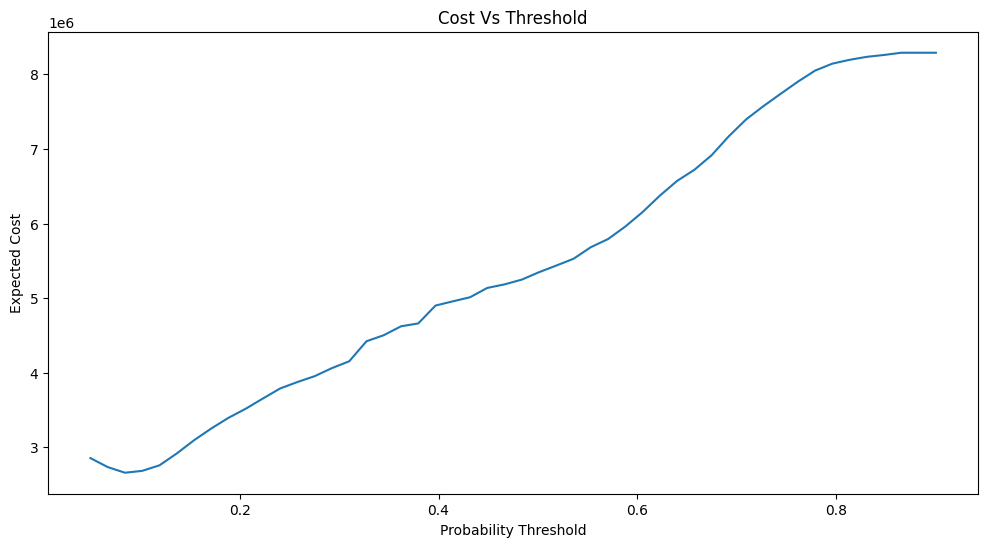

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(thresholds, costs)
plt.xlabel("Probability Threshold")
plt.ylabel("Expected Cost")
plt.title("Cost Vs Threshold")
plt.show()

#### What the Curve Shows

- X-axis: Probability threshold used to flag customers as high risk

- Y-axis: Total expected financial cost

- Missed defaulters (False Negatives × $5,000)

- Unnecessary interventions (False Positives × $500)

#### Key Observations

- Minimum cost occurs at low–moderate thresholds (~0.10–0.15)

- This is where false negatives are minimized

- Early detection prevents expensive charge-offs

- Cost increases steadily as threshold rises

- Higher thresholds miss more true defaulters

- Each missed defaulter is 10× more expensive than unnecessary contact

- High thresholds (>0.6) are financially dangerous

- Model becomes overly conservative

- Defaults occur without intervention

- Losses escalate sharply

### Business Interpretation

In credit risk management, missing a defaulter is significantly more expensive than intervening with a safe customer.

The cost curve confirms that an aggressive early-warning strategy is financially optimal, even if it results in higher operational workload.

#### Recommended Operating Threshold

- Primary intervention threshold: 0.12

- Optimizes expected financial loss

- Aligns with early warning objectives

#### Tiered Risk Strategy
|Risk Tier|	Probability| Range|	Action|
- Low Risk	< 0.13	No action
- Medium Risk	0.13 – 0.42	Soft reminder / monitoring
- High Risk	> 0.42	Immediate intervention

Thresholds are driven by money, not accuracy.

Cost-sensitive analysis demonstrates that optimal decision thresholds are materially lower than traditional classification cutoffs.

Due to asymmetric error costs, early identification of potential defaulters minimizes expected loss, even at the expense of increased false positives.

This framework ensures that model deployment decisions are aligned with real financial outcomes rather than abstract performance metrics.